# Predictive Maintenance of Industrial Machinery 
# submission by Anushka
### Mechanical Engineering – Machine Learning Project (Problem Statement No. 39)

**Goal:** Build a classification model that predicts the *type* of machine failure (Tool Wear, Heat Dissipation, Power Failure, Overstrain, Random Failure, or No Failure) using real-time operational sensor data, enabling proactive maintenance.

**Dataset:** [Machine Predictive Maintenance Classification (Kaggle)](https://www.kaggle.com/datasets/shivamb/machine-predictive-maintenance-classification)

**Technology requirement:** IBM Cloud Lite services (see the last section for how to deploy this model using IBM Watson Studio / Watson Machine Learning Lite).

## 1. Import Libraries

In [23]:
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

## 2. Load the Dataset

Update the path below if your CSV is stored elsewhere.

In [2]:
csv_data = wslib.load_data("predictive_maintenance.csv")
df = pd.read_csv(csv_data)
print("Shape:", df.shape)
df.head()


Shape: (10000, 10)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


## 3. Initial Exploration

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [4]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

Duplicate rows: 0


### Target distribution

The dataset has two related targets:
- **`Target`** — binary (0 = No Failure, 1 = Failure)
- **`Failure Type`** — multi-class (what we will predict, as required by the problem statement)

Note the strong class imbalance — most machines are healthy at any given observation.

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64

Failure Type
No Failure                  96.52
Heat Dissipation Failure     1.12
Power Failure                0.95
Overstrain Failure           0.78
Tool Wear Failure            0.45
Random Failures              0.18
Name: proportion, dtype: float64


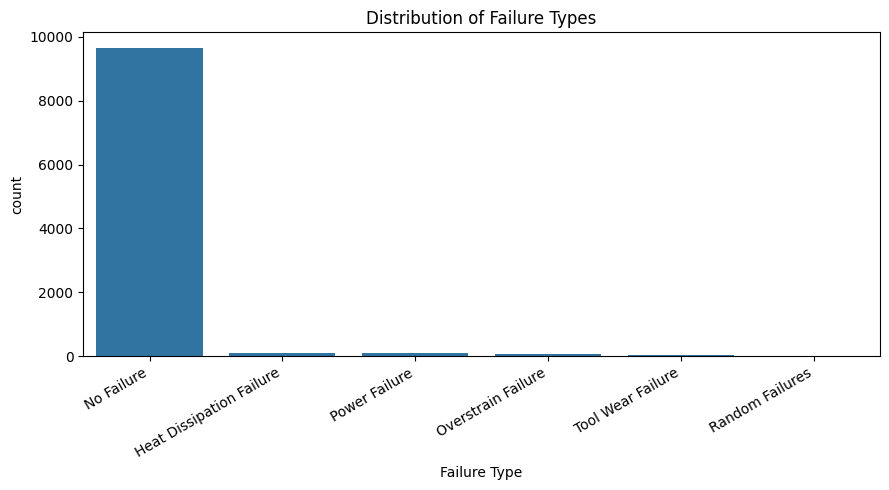

In [6]:
print(df['Failure Type'].value_counts())
print()
print(df['Failure Type'].value_counts(normalize=True) * 100)

plt.figure(figsize=(9,5))
sns.countplot(data=df, x='Failure Type', order=df['Failure Type'].value_counts().index)
plt.xticks(rotation=30, ha='right')
plt.title('Distribution of Failure Types')
plt.tight_layout()
plt.show()

## 4. Exploratory Data Analysis (EDA)

Let's look at how sensor readings differ across failure types.

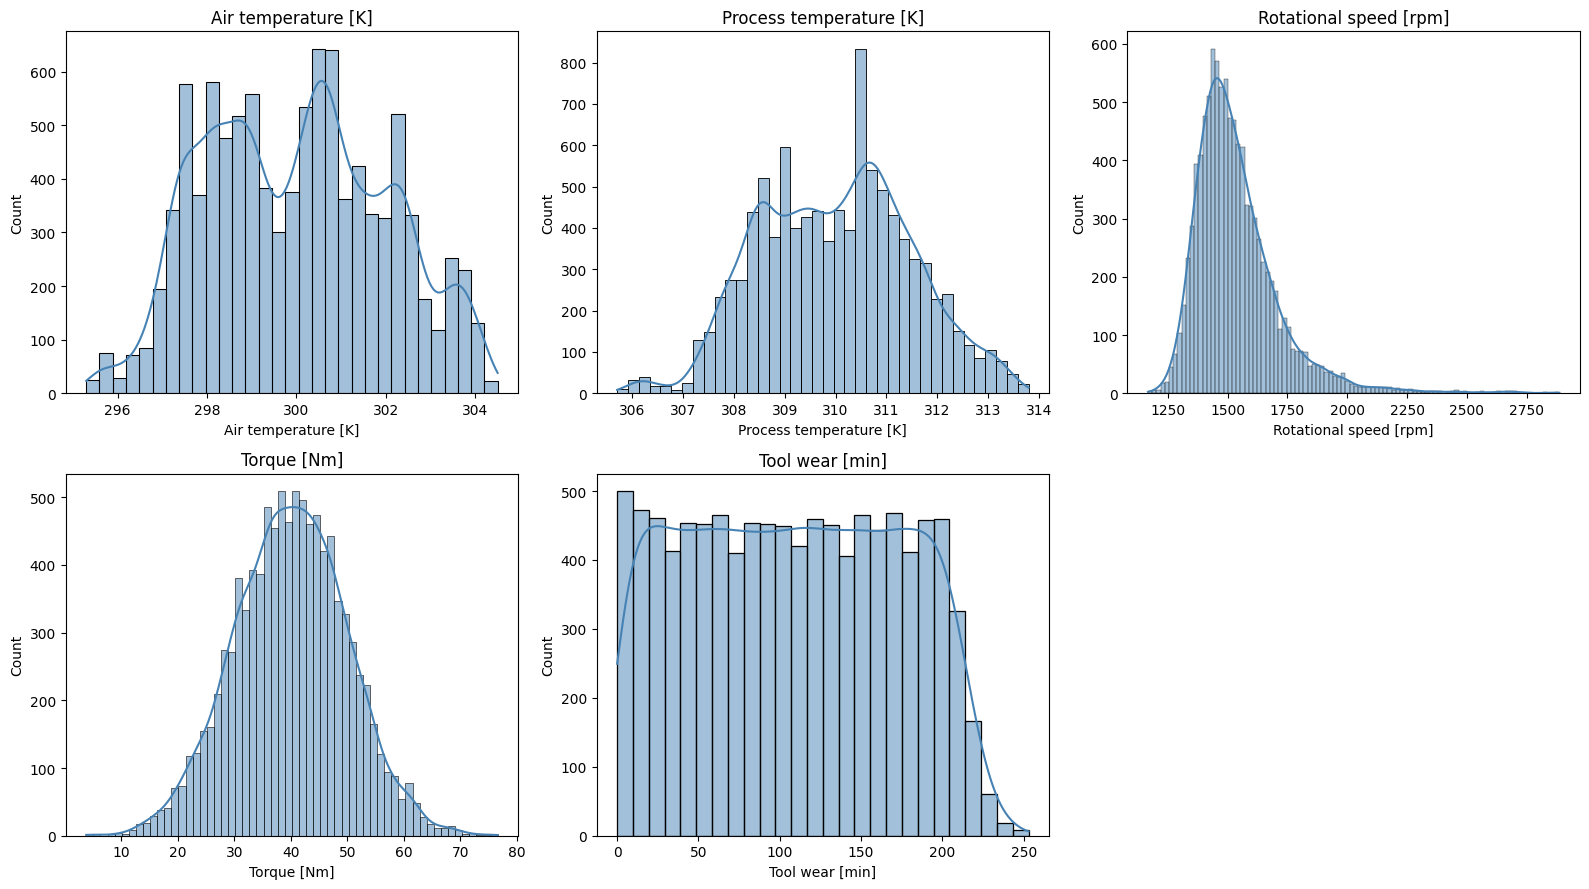

In [7]:
num_cols = ['Air temperature [K]', 'Process temperature [K]',
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

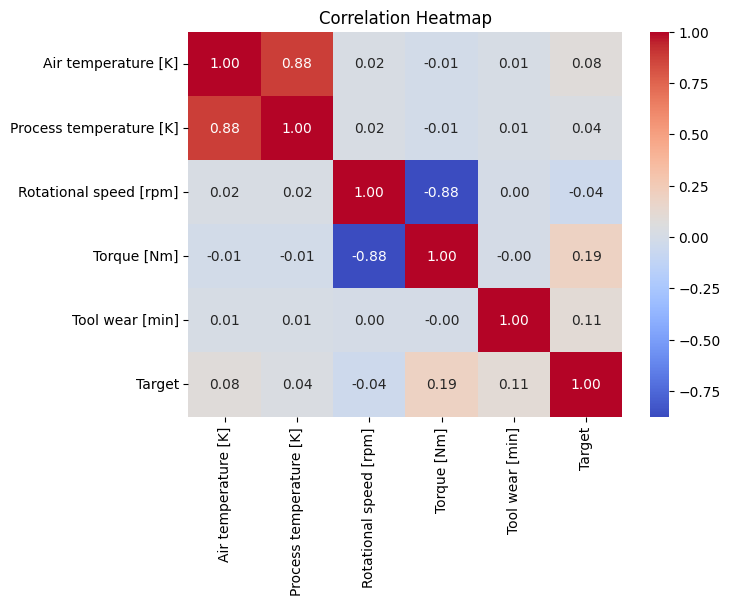

In [8]:
# Correlation heatmap of numeric features
plt.figure(figsize=(7,5))
sns.heatmap(df[num_cols + ['Target']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

/tmp/wsuser/ipykernel_516/153765879.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
/tmp/wsuser/ipykernel_516/153765879.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
/tmp/wsuser/ipykernel_516/153765879.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
/tmp/wsuser/ipykernel_516/153765879.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
/tmp/wsu

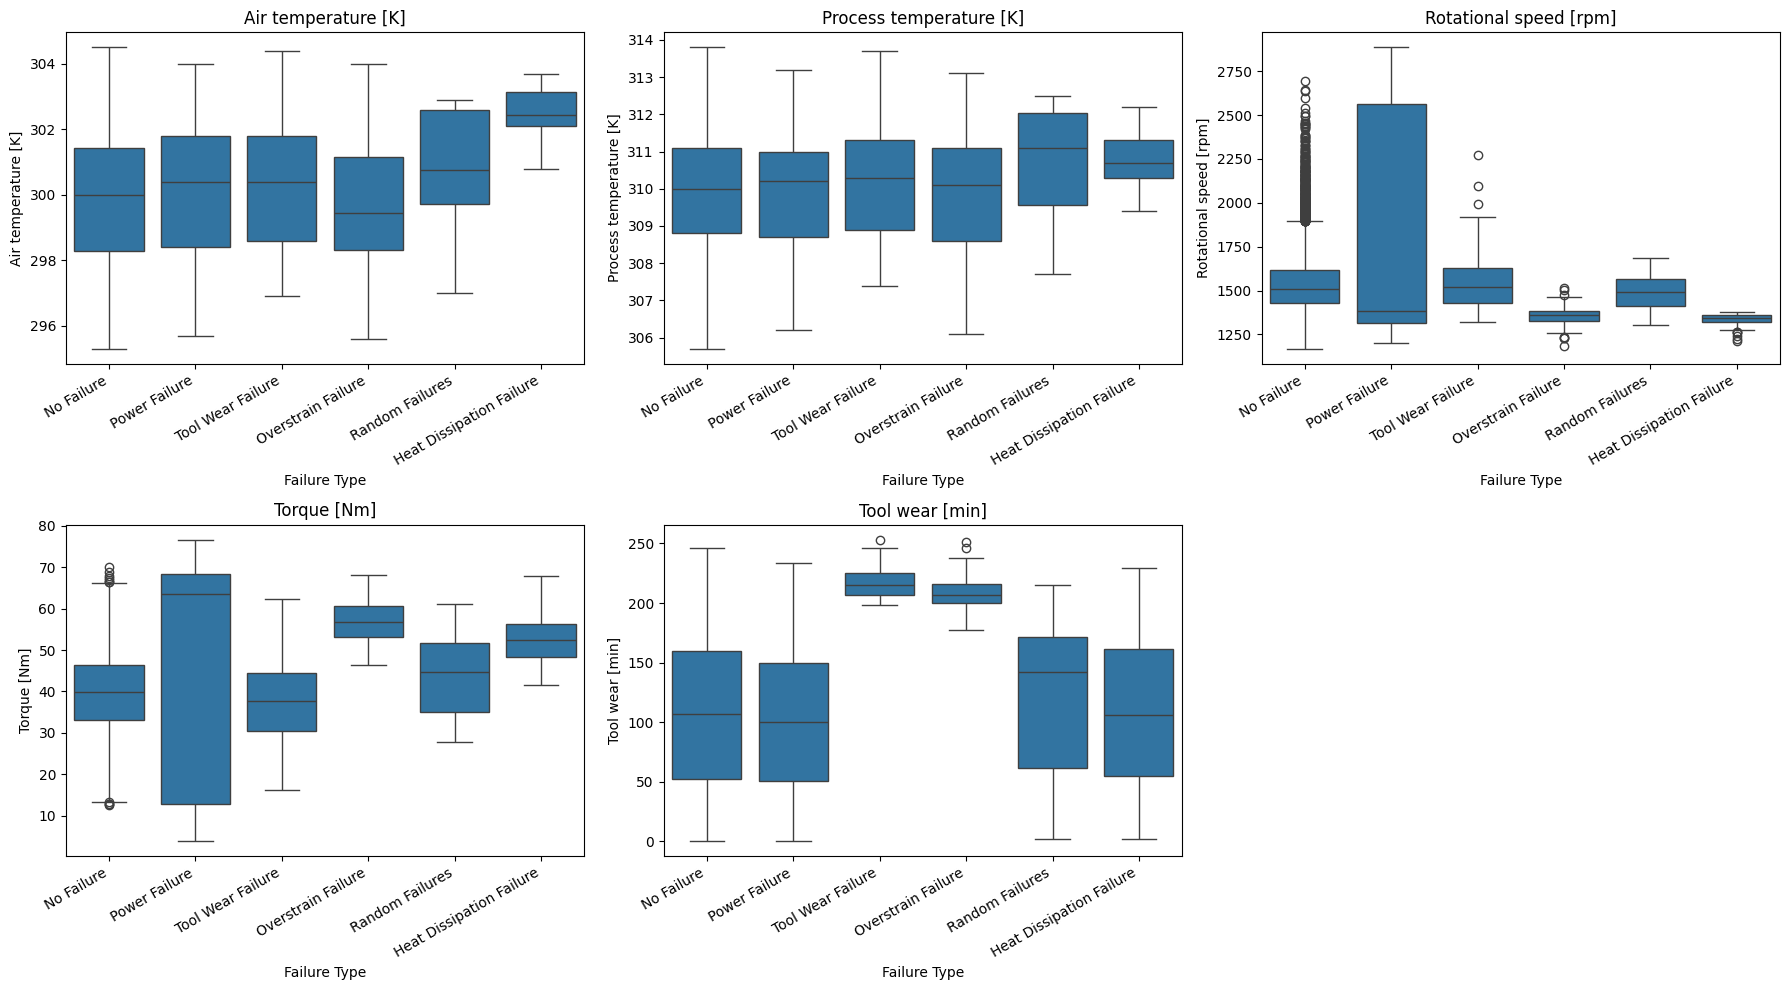

In [9]:
# How sensor readings vary by failure type (boxplots)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='Failure Type', y=col, ax=axes[i])
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
    axes[i].set_title(col)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

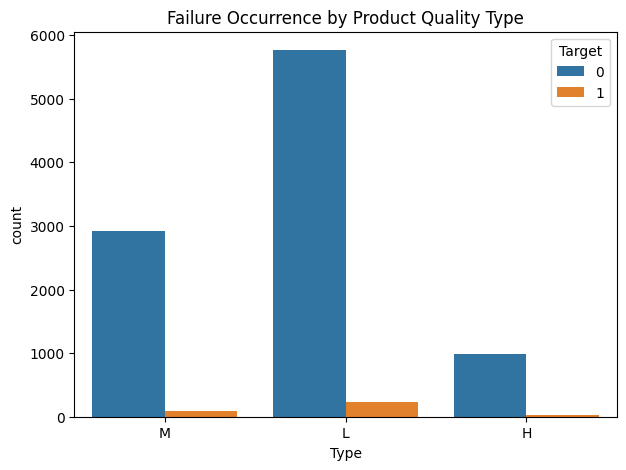

In [10]:
# Failure counts by machine Type (L/M/H quality variants)
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='Type', hue='Target')
plt.title('Failure Occurrence by Product Quality Type')
plt.show()

## 5. Feature Engineering & Preprocessing

Steps:
1. Drop identifier columns (`UDI`, `Product ID`) — they carry no predictive signal.
2. Encode the categorical `Type` column (L/M/H → 0/1/2).
3. Create a derived feature: **Power [W] = Torque × Rotational speed** (a known physically meaningful feature for this dataset).
4. Create **Temp difference = Process temperature − Air temperature**.
5. Encode the target `Failure Type` with `LabelEncoder`.
6. Scale numeric features with `StandardScaler`.

In [11]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

In [12]:
data = df.copy()

# Drop identifiers
data = data.drop(columns=['UDI', 'Product ID'])

# Encode machine quality Type
type_encoder = LabelEncoder()
data['Type'] = type_encoder.fit_transform(data['Type'])   # L=1, M=2, H=0 (alphabetical)

# Derived physics-based features
data['Power [W]'] = data['Torque [Nm]'] * (data['Rotational speed [rpm]'] * 2 * np.pi / 60)
data['Temp diff [K]'] = data['Process temperature [K]'] - data['Air temperature [K]']

# Encode target (multi-class failure type)
target_encoder = LabelEncoder()
data['Failure Type Encoded'] = target_encoder.fit_transform(data['Failure Type'])

print(dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))
data.head()

{'Heat Dissipation Failure': np.int64(0), 'No Failure': np.int64(1), 'Overstrain Failure': np.int64(2), 'Power Failure': np.int64(3), 'Random Failures': np.int64(4), 'Tool Wear Failure': np.int64(5)}


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type,Power [W],Temp diff [K],Failure Type Encoded
0,2,298.1,308.6,1551,42.8,0,0,No Failure,6951.590560,10.5,1
1,1,298.2,308.7,1408,46.3,3,0,No Failure,6826.722724,10.5,1
2,1,298.1,308.5,1498,49.4,5,0,No Failure,7749.387543,10.4,1
3,1,298.2,308.6,1433,39.5,7,0,No Failure,5927.504659,10.4,1
4,1,298.2,308.7,1408,40.0,9,0,No Failure,5897.816608,10.5,1


In [13]:
# Drop the raw binary Target and text Failure Type - we'll predict Failure Type Encoded
X = data.drop(columns=['Target', 'Failure Type', 'Failure Type Encoded'])
y = data['Failure Type Encoded']

feature_names = X.columns.tolist()
print("Features used:", feature_names)

Features used: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Power [W]', 'Temp diff [K]']


## 6. Train / Test Split + Scaling

We use a **stratified** split so rare failure classes are represented proportionally in both sets.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (8000, 8)  Test shape: (2000, 8)


## 7. Handling Class Imbalance with SMOTE

Rare failure types (e.g. *Random Failures* with only 18 samples) are very hard for a model to learn without resampling. We apply **SMOTE** (Synthetic Minority Over-sampling) on the *training set only* to avoid data leakage.

In [15]:
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", pd.Series(y_train).value_counts().to_dict())
print("After SMOTE :", pd.Series(y_train_res).value_counts().to_dict())


Before SMOTE: {1: 7722, 0: 90, 3: 76, 2: 62, 5: 36, 4: 14}
After SMOTE : {1: 7722, 5: 7722, 4: 7722, 3: 7722, 0: 7722, 2: 7722}


## 8. Model Training — Random Forest Classifier

Random Forest is a strong baseline for tabular sensor data: robust to feature scaling, handles non-linear relationships, and gives interpretable feature importances (useful for engineers diagnosing *why* a failure is predicted).

In [16]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_res, y_train_res)

y_pred = rf.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Weighted F1 Score:", f1_score(y_test, y_pred, average='weighted'))

Test Accuracy: 0.981
Weighted F1 Score: 0.9814836278506806


## 9.Model Evaluation

In [17]:
print(classification_report(
    y_test, y_pred,
    target_names=target_encoder.classes_,
    zero_division=0
))

                          precision    recall  f1-score   support

Heat Dissipation Failure       0.92      1.00      0.96        22
              No Failure       0.99      0.99      0.99      1930
      Overstrain Failure       0.83      0.62      0.71        16
           Power Failure       1.00      1.00      1.00        19
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.00      0.00      0.00         9

                accuracy                           0.98      2000
               macro avg       0.62      0.60      0.61      2000
            weighted avg       0.98      0.98      0.98      2000



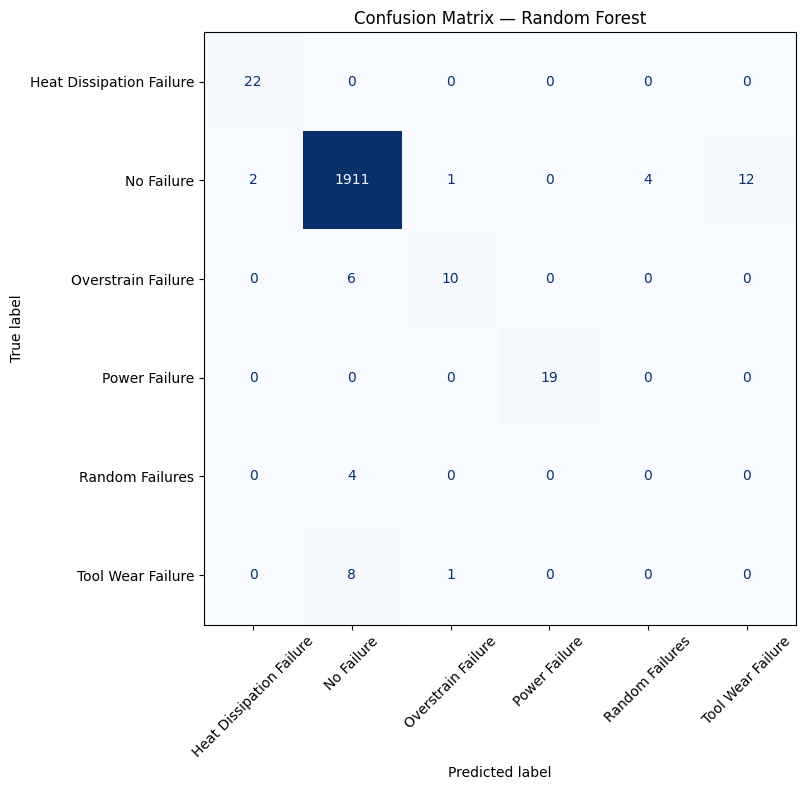

In [18]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(9,8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_encoder.classes_)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
plt.title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.show()

/tmp/wsuser/ipykernel_516/1894741841.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


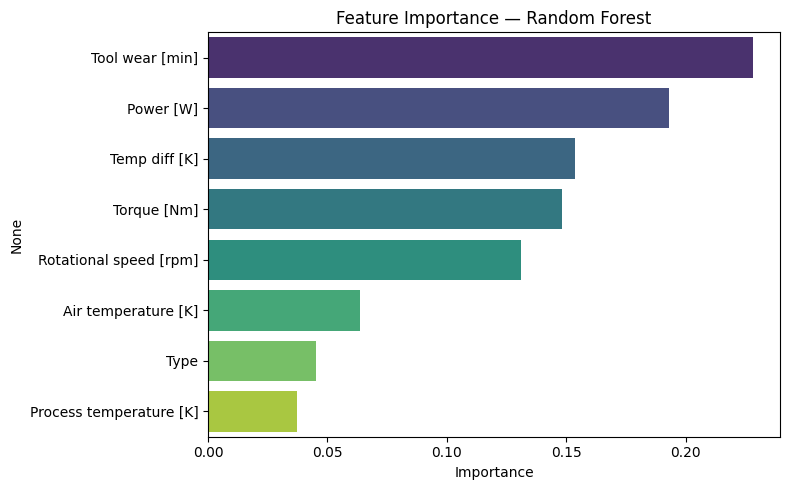

Tool wear [min]            0.228163
Power [W]                  0.192882
Temp diff [K]              0.153652
Torque [Nm]                0.148202
Rotational speed [rpm]     0.131211
Air temperature [K]        0.063522
Type                       0.045219
Process temperature [K]    0.037149
dtype: float64

In [19]:
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importances

## 10. Hyperparameter Tuning (optional but recommended)

A small `GridSearchCV` to squeeze out extra performance. This can take a minute or two to run.

In [20]:
param_grid = {
    'n_estimators': [150, 250],
    'max_depth': [None, 15],
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=3,
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train_res, y_train_res)

print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

best_rf = grid.best_estimator_
y_pred_best = best_rf.predict(X_test_scaled)
print("Tuned Test Accuracy:", accuracy_score(y_test, y_pred_best))
print("Tuned Weighted F1:", f1_score(y_test, y_pred_best, average='weighted'))

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best params: {'max_depth': None, 'n_estimators': 250}
Best CV F1: 0.9967105728294682
Tuned Test Accuracy: 0.9815
Tuned Weighted F1: 0.9820860390178161


## 11. Save the Final Model

We persist the trained model, scaler, and encoders so they can be reused for inference — including deployment to **IBM Watson Machine Learning (Lite plan)**.

In [21]:
final_model = best_rf if grid.best_score_ >= f1_score(y_test, y_pred, average='weighted') else rf

joblib.dump(final_model, 'predictive_maintenance_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(type_encoder, 'type_encoder.pkl')
joblib.dump(target_encoder, 'target_encoder.pkl')

print("Saved: predictive_maintenance_model.pkl, scaler.pkl, type_encoder.pkl, target_encoder.pkl")

Saved: predictive_maintenance_model.pkl, scaler.pkl, type_encoder.pkl, target_encoder.pkl


## 12. Sample Prediction Function

Use this to simulate real-time predictions on new sensor readings.

In [22]:
def predict_failure(air_temp, process_temp, rot_speed, torque, tool_wear, machine_type='M'):
    """
    machine_type: 'L', 'M', or 'H'
    Returns predicted failure type as a string.
    """
    type_val = type_encoder.transform([machine_type])[0]
    power = torque * (rot_speed * 2 * np.pi / 60)
    temp_diff = process_temp - air_temp

    row = pd.DataFrame([{
        'Type': type_val,
        'Air temperature [K]': air_temp,
        'Process temperature [K]': process_temp,
        'Rotational speed [rpm]': rot_speed,
        'Torque [Nm]': torque,
        'Tool wear [min]': tool_wear,
        'Power [W]': power,
        'Temp diff [K]': temp_diff
    }])[feature_names]

    row_scaled = scaler.transform(row)
    pred = final_model.predict(row_scaled)[0]
    return target_encoder.inverse_transform([pred])[0]

# Example
sample_pred = predict_failure(
    air_temp=300.5, process_temp=310.2, rot_speed=1400,
    torque=55.0, tool_wear=200, machine_type='L'
)
print("Predicted Failure Type:", sample_pred)

Predicted Failure Type: Overstrain Failure


## 13. Conclusion

- Built a multi-class classifier that predicts the **type** of machine failure from operational sensor data.
- Addressed severe class imbalance using **SMOTE**.
- **Random Forest** with engineered physical features (Power, Temp difference) gave strong performance, and feature importance highlights which sensors matter most — useful for maintenance engineers.
- Outlined the path to deploy this model on **IBM Cloud Lite (Watson Studio + Watson Machine Learning)** to satisfy the mandated technology requirement.